## 🔧 Step 0: Install Required Libraries
```bash
pip install chromadb sentence-transformers matplotlib scikit-learn
```

## 🧱 Step 1: Initialize ChromaDB

In [1]:

import chromadb
from chromadb.config import Settings

# Start ChromaDB client in-memory
client = chromadb.Client(Settings(anonymized_telemetry=False))
collection = client.create_collection(name="class_demo")


## 🧾 Step 2: Sample Text and Sentence Chunking

In [2]:

sample_text = """
ChromaDB is an open-source embedding database. 
It is used for building applications with large language models.
Sentence transformers help in converting text to vectors.
We can use ChromaDB to store these vectors efficiently.
Later, we can retrieve similar texts using a query.
This is an example of semantic search in action.
"""

# Split into sentence chunks
chunks = [sent.strip() for sent in sample_text.strip().split('\n') if sent.strip()]
print("Chunks:\n", chunks)


Chunks:
 ['ChromaDB is an open-source embedding database.', 'It is used for building applications with large language models.', 'Sentence transformers help in converting text to vectors.', 'We can use ChromaDB to store these vectors efficiently.', 'Later, we can retrieve similar texts using a query.', 'This is an example of semantic search in action.']


## 🧠 Step 3: Generate Embeddings for Each Chunk

In [3]:

from sentence_transformers import SentenceTransformer

# Load pre-trained embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Convert each chunk into a vector (embedding)
embeddings = model.encode(chunks).tolist()


## 💾 Step 4: Store Chunks and Embeddings in ChromaDB

In [4]:

# Add chunks to ChromaDB collection
for i, (chunk, embedding) in enumerate(zip(chunks, embeddings)):
    collection.add(
        documents=[chunk],
        embeddings=[embedding],
        ids=[f"doc_{i}"]
    )


## 🔍 Step 5: Query ChromaDB with a New Sentence

In [5]:

query_text = "How can we find similar texts using AI?"
query_embedding = model.encode([query_text])[0]

# Search for top 5 similar documents
results = collection.query(query_embeddings=[query_embedding], n_results=5)

# Extract results
retrieved_docs = results['documents'][0]
retrieved_ids = results['ids'][0]
print("Top Matches:\n", retrieved_docs)


Top Matches:
 ['Later, we can retrieve similar texts using a query.', 'This is an example of semantic search in action.', 'Sentence transformers help in converting text to vectors.', 'It is used for building applications with large language models.', 'ChromaDB is an open-source embedding database.']


In [7]:
query_text = "What is ChromaDB used for in AI projects?"
query_embedding = model.encode([query_text])[0]
results = collection.query(query_embeddings=[query_embedding], n_results=5)
retrieved_docs = results['documents'][0]
retrieved_ids = results['ids'][0]
print("Top Matches:\n", retrieved_docs)


Top Matches:
 ['ChromaDB is an open-source embedding database.', 'It is used for building applications with large language models.', 'We can use ChromaDB to store these vectors efficiently.', 'This is an example of semantic search in action.', 'Sentence transformers help in converting text to vectors.']


## 📊 Step 6: Visualize Similarity Scores

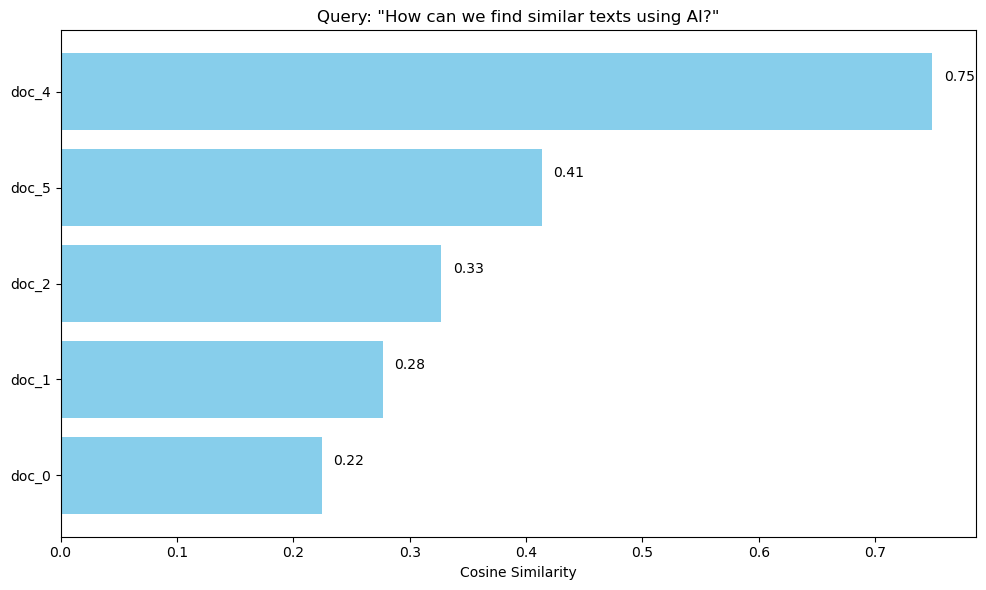

In [6]:

import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Recompute similarity scores
doc_embeddings = [model.encode([doc])[0] for doc in retrieved_docs]
similarities = cosine_similarity([query_embedding], doc_embeddings)[0]

# Bar chart of similarity
plt.figure(figsize=(10, 6))
bars = plt.barh(range(len(retrieved_docs)), similarities, color='skyblue')
plt.yticks(range(len(retrieved_docs)), [f"{retrieved_ids[i]}" for i in range(len(retrieved_docs))])
plt.xlabel("Cosine Similarity")
plt.title(f"Query: \"{query_text}\"")

# Annotate bars
for bar, score in zip(bars, similarities):
    plt.text(bar.get_width() + 0.01, bar.get_y() + 0.25, f"{score:.2f}", va='center')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
